<a href="https://colab.research.google.com/github/Sanggoldsilver/Colab_archive/blob/main/%ED%86%B5%EA%B3%84%EB%A1%9C_%EC%9A%94%EC%95%BD%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown
gdown.download('https://bit.ly/3736JW1', 'ns_book6.csv', quiet=False)

Downloading...
From: https://bit.ly/3736JW1
To: /content/ns_book6.csv
100%|██████████| 55.0M/55.0M [00:01<00:00, 52.3MB/s]


'ns_book6.csv'

In [ ]:
import pandas as pd
ns_book6 = pd.read_csv('ns_book6.csv', low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,인공지능과 흙,김동훈 지음,민음사,2021.0,9788937444319,NaN,NaN,NaN,NaN,1,0,2021-03-19
1,2,가짜 행복 권하는 사회,김태형 지음,갈매나무,2021.0,9791190123969,NaN,NaN,NaN,NaN,1,0,2021-03-19
2,3,나도 한 문장 잘 쓰면 바랄 게 없겠네,김선영 지음,블랙피쉬,2021.0,9788968332982,NaN,NaN,NaN,NaN,1,0,2021-03-19
3,4,예루살렘 해변,"이도 게펜 지음, 임재희 옮김",문학세계사,2021.0,9788970759906,NaN,NaN,NaN,NaN,1,0,2021-03-19
4,5,김성곤의 중국한시기행 : 장강·황하 편,김성곤 지음,김영사,2021.0,9788934990833,NaN,NaN,NaN,NaN,1,0,2021-03-19


In [ ]:
#기술 통계를 자동으로 추출해주는 describe() 메서드
ns_book6.describe()

,번호,발행년도,도서권수,대출건수
count,379976.000000,379976.000000,379976.000000,379976.000000
mean,201726.332847,2008.516306,1.135874,11.504629
std,115836.454596,8.780529,0.483343,19.241926
min,1.000000,1947.000000,0.000000,0.000000
25%,102202.750000,2003.000000,1.000000,2.000000
50%,203179.500000,2009.000000,1.000000,6.000000
75%,301630.250000,2015.000000,1.000000,14.000000
max,401681.000000,2650.000000,40.000000,1765.000000


In [ ]:
sum(ns_book6['도서권수']==0) #<-'도서권수' 열의 값이 0인 행 개수를 센다잉

3206

In [ ]:
#0인 도서 대출 데이터 제외
ns_book7 = ns_book6[ns_book6['도서권수']>0]

In [ ]:
x = [10, 20, 30]
sum = 0
for i in range(3) :
  sum += x[i]
print("평균:", sum / len(x))

평균: 20.0


In [ ]:
#Range() 함수는 하나의 숫자를 입력할 경우 0부터 입력된 숫자 직전까지 반복할 수 있는 객체를 만들어줌
ns_book7['대출건수'].mean()

np.float64(11.593438968070707)

In [ ]:
ns_book7['대출건수'].median()

6.0

In [ ]:
#데이터 개수가 짝수이면 가운데 두 개의 값을 평균하여 중앙값을 결정
temp_df = pd.DataFrame([1, 2, 3, 4])
temp_df.median()

,0
0,2.5


In [ ]:
#중복값 제거하고 중앙값 구하기
#drop_duplicates() 메서드를 사용해 '대출건수' 열에서 중복된 값을 가진 행을 제거한 후 중앙값 계산
ns_book7['대출건수'].drop_duplicates().median()

183.0

In [ ]:
#최솟값, 최댓값 구하기
ns_book7['대출건수'].min()

0

In [ ]:
ns_book7['대출건수'].max()

1765

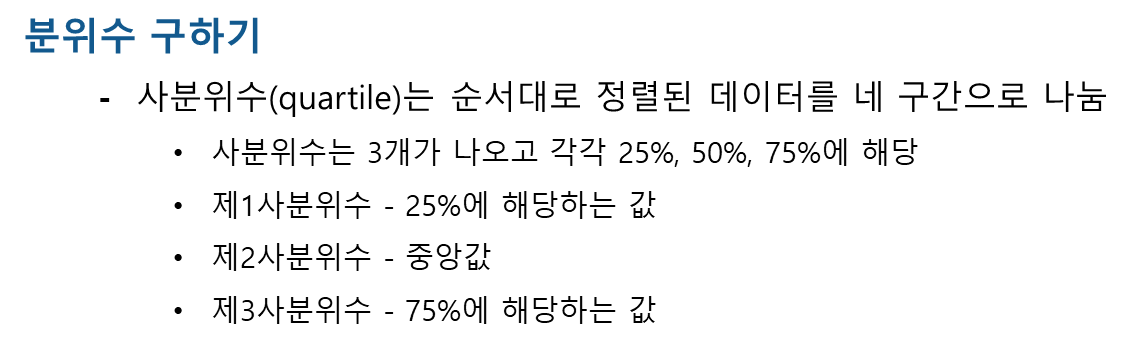

In [ ]:
#Quantile() 하위 25% 위치 값 출력하려면 0.25 입력
ns_book6['대출건수'].quantile(0.25)

np.float64(2.0)

In [ ]:
#quantile() 메서드에 여러 개의 분위수 지정
ns_book6['대출건수'].quantile([0.25,0.5,0.75])

,대출건수
0.25,2.0
0.50,6.0
0.75,14.0


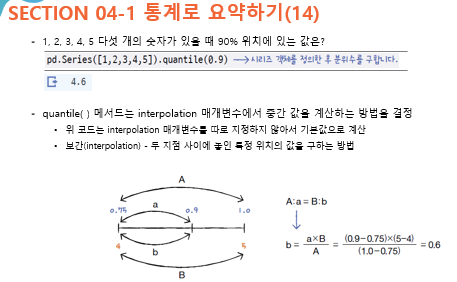

In [ ]:
pd.Series([1,2,3,4,5]).quantile(0.9) #시리즈 객체를 정의한 후 분위수를 구함

np.float64(4.6)

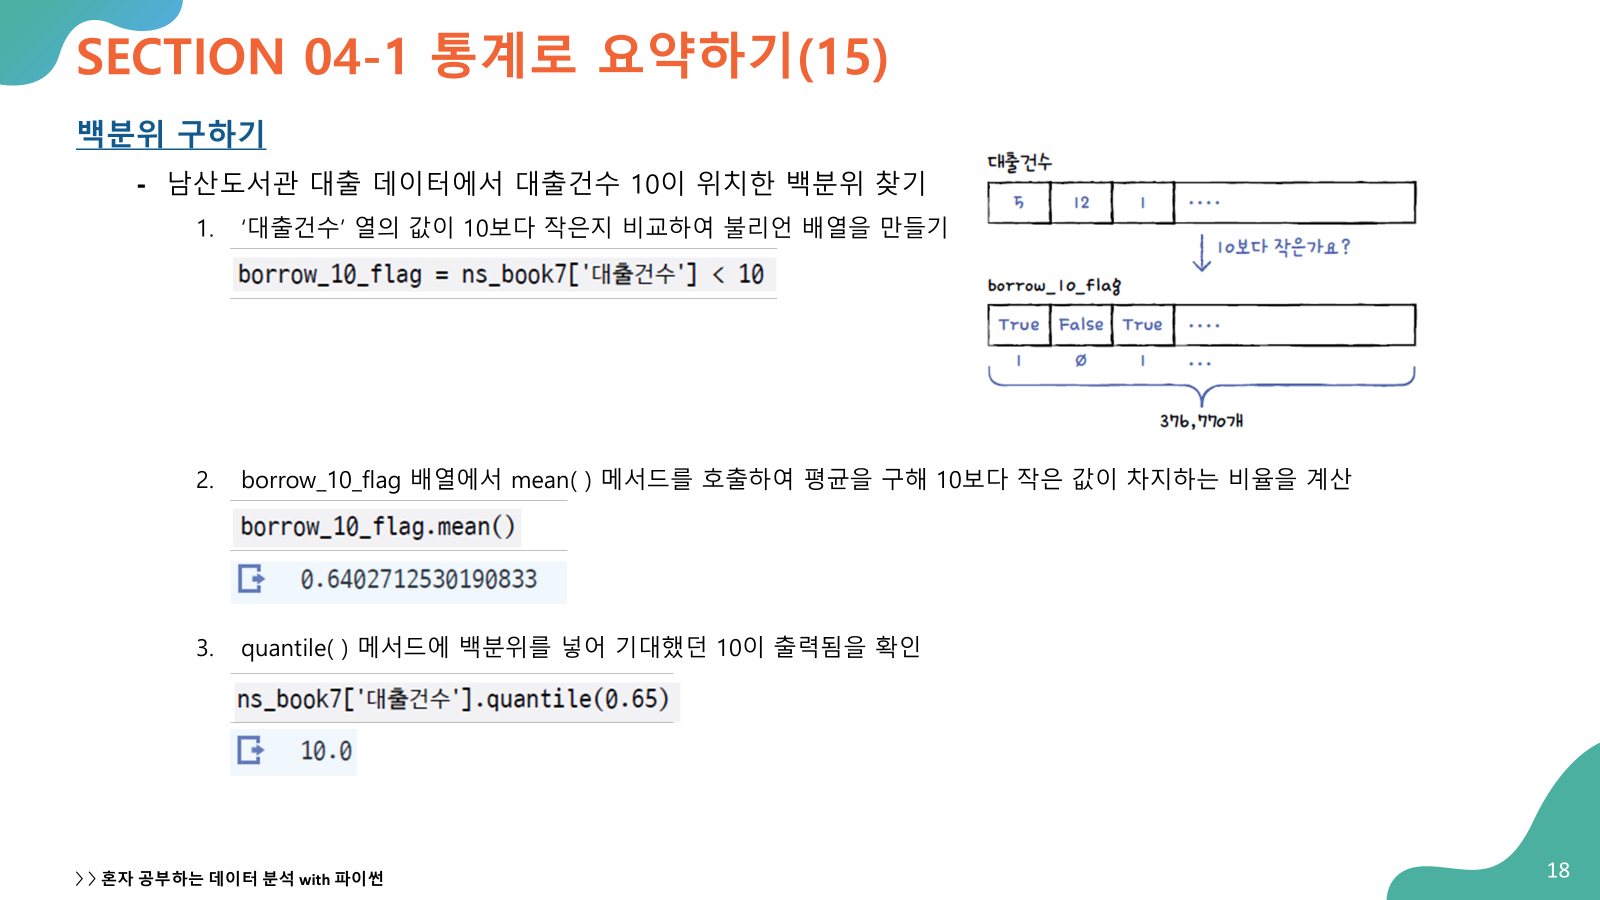

In [ ]:
borrow_10_flag = ns_book7['대출건수'] <10
borrow_10_flag.mean()


np.float64(0.6402712530190833)

In [ ]:
ns_book7['대출건수'].quantile(0.65)

np.float64(10.0)

In [ ]:
#분산 구하기
#평균으로부터 데이터가 얼마나 퍼져있는지를 나타내는 통계량
#데이터의 각 값에서 평균을 뺀 다음 제곱한 후 평균처럼 샘플 개수로 나누어 계산
ns_book7['대출건수'].var()

371.6956304306922

In [ ]:
#표준편차 구하기
#표준편차 - 분산에 제곱근을 한 것으로 수식 기호는 S를 사용
#std() 메서드를 사용하여 대출건수의 표준편차를 계산
ns_book6['대출건수'].std()

19.241925726331733

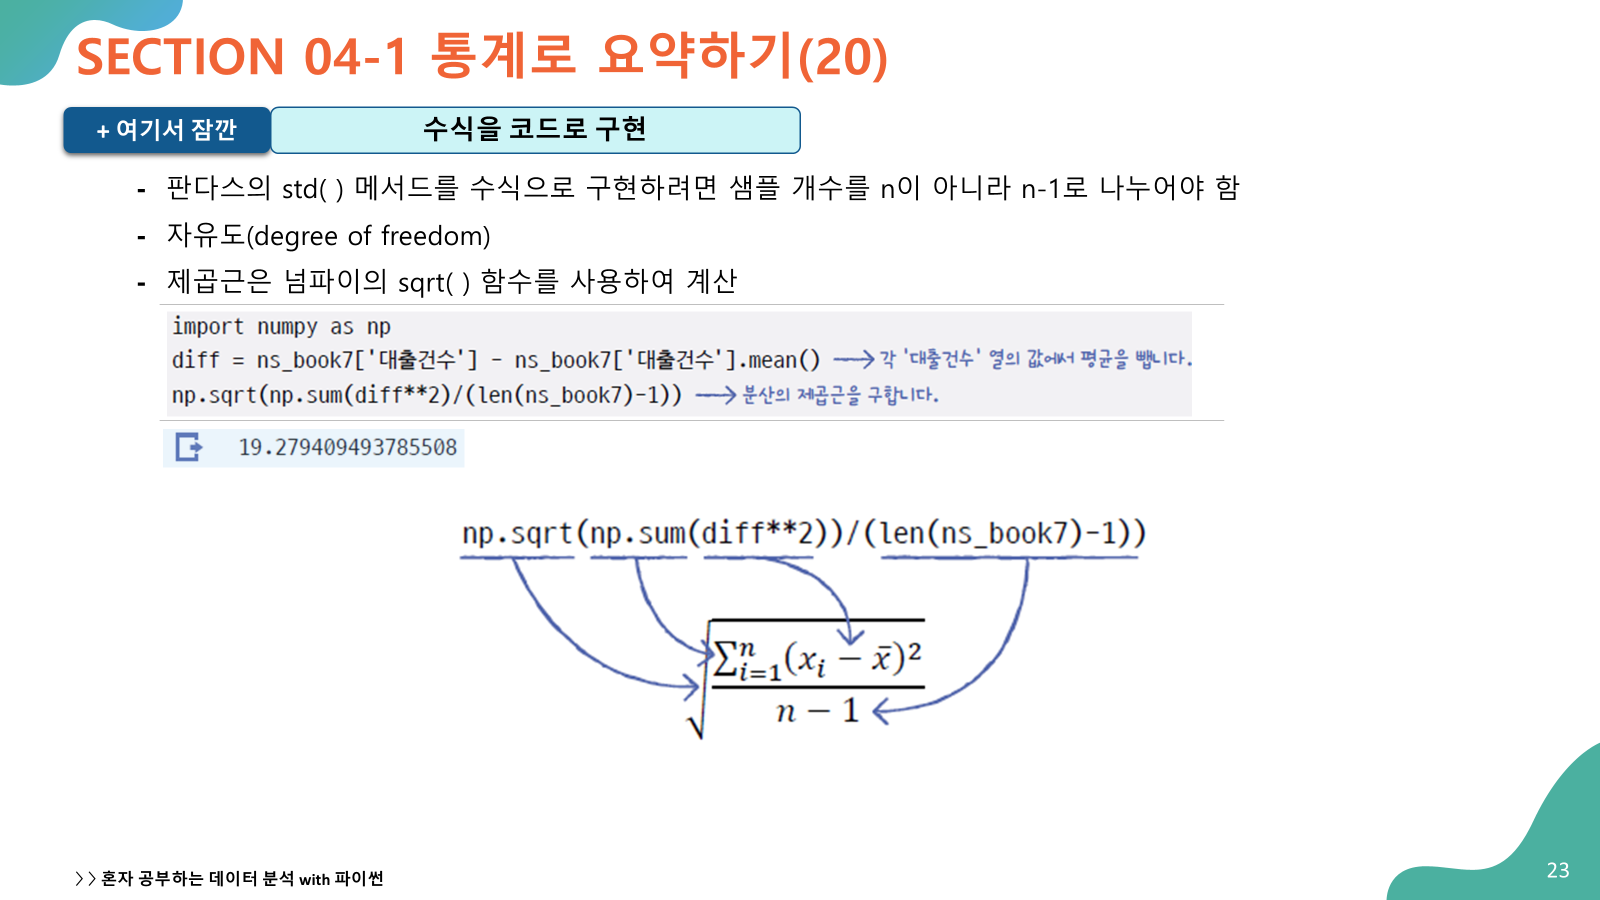

In [ ]:
import numpy as np
diff = ns_book7['대출건수'] - ns_book7['대출건수'].mean() #-> 각 '대출건수'열의 값에서 평균을 빼기
np.sqrt(np.sum(diff**2)/(len(ns_book7)-1)) #-> 분산의 제곱근 구하기

np.float64(19.279409493785508)

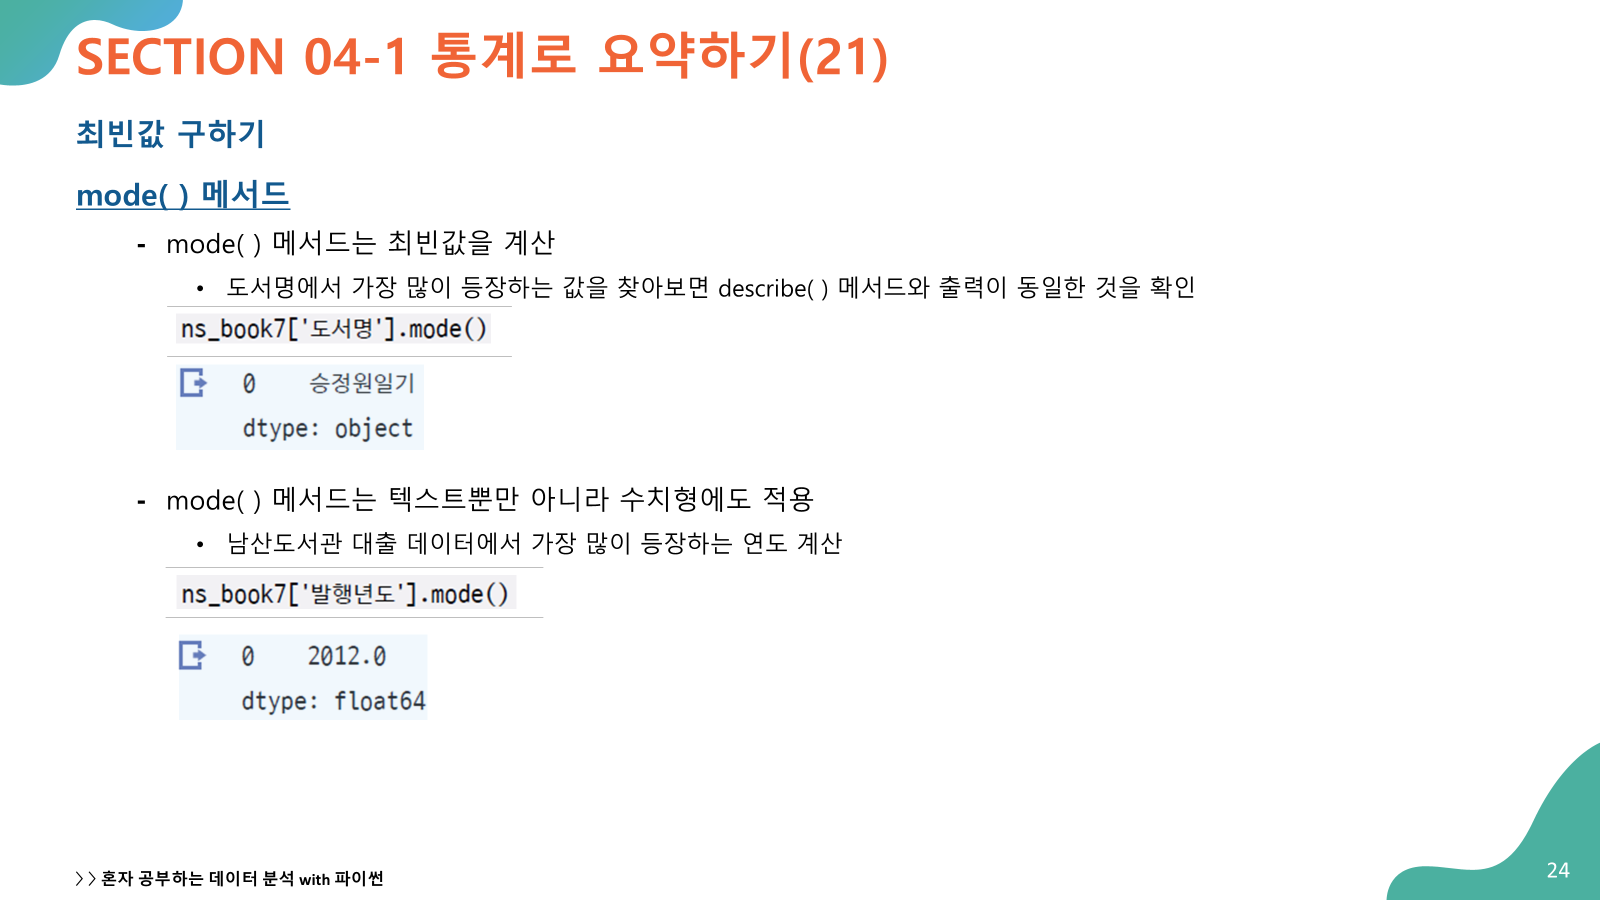

In [ ]:
#mode()는 최빈값 계산
ns_book7['도서명'].mode()

,도서명
0,승정원일기


In [ ]:
#mode()는 텍스트뿐만 아니라 수치형에도 적용
ns_book7['발행년도'].mode()

,발행년도
0,2012.0


In [ ]:
#수치형 열만 연산할 수 있기 때문에 해당 열에만 적용되도록 numeriic_only 매개변수를 True로 지정
ns_book7.mean(numeric_only=True)

,0
번호,202977.476649
발행년도,2008.460076
도서권수,1.145540
대출건수,11.593439


In [ ]:
#loc 메서드로 '도서명' 열부터 마지막 열까지에 대해 최빈값을 찾기
ns_book7.loc[:, '도서명':].mode()

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012.0,9788937430299,9788937460005,0,1,813.6,1,0,1970-01-01


In [ ]:
#확인문제 전까지만 하면 된다 하심 강의

In [ ]:
ns_book7.to_csv('ns_book7.csv', index=False)